In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def matrix_multiplication(m_1: np.ndarray, m_2: np.ndarray)-> np.ndarray:
    """Recibe dos matrices Numpy de dimensiones compatibles 
    y devuelve otra matriz Numpy con su producto."""
    rows1, cols1 = m_1.shape
    rows2, cols2 = m_2.shape
    try:
        m_3 = np.zeros(shape=(rows1, cols2), dtype=int)
        if cols1 == rows2:
            for i in range(0,rows1):
                for j in range(0, cols2):
                    for n in range(0, rows2):
                        m_3[i][j] += m_1[i][n] * m_2[n][j]
    except:
        print("Error al multipicar matrices")
    else:
        return m_3

In [15]:
l_timings=[]
l_timingsd=[]
for i in range(1,100,10):
    dim = 10+i
    try:
        m = np.random.uniform(0., 1., (dim, dim))
        timings = %timeit -o -n 1 -r 1 -q matrix_multiplication(m, m) 
        l_timings.append([dim, timings.best])
        timings = %timeit -o -n 100 -r 50 -q m.dot(m)
        l_timingsd.append([dim, timings.best])
    except:
        print("Error calculando tiempos de ejecución")

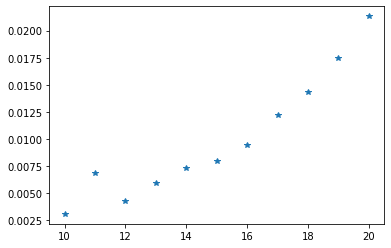

In [5]:
l_timings
la=np.array(l_timings)
x=la[:,0]
y=la[:,1]
x,y
plt.plot(x,y,'*')

In [6]:
z=np.polyfit(x,y,3)
z

array([ 1.71184905e-05, -5.90671114e-04,  7.48474478e-03, -2.89303392e-02])

In [7]:
def bb(t: list, f: int, l: int, key: int)-> int:
    """ Recibe una lista, sus  ́ındices first, last primero y  ́ultimo, y una clave key , 
    y encuentra la posicion de key entre first y last.
    Si no la encuentra, devuelve None ."""
    medio: int
    try:
        while f <= l:
            medio= (f+l)//2
            if t[medio]== key:
                return medio
            elif t[medio] > key:
                l = medio-1
            else:
                f = medio+1
    except:
        print("Error en la busqueda binaria")
    else:
        return None

def rec_bb(t: list, f: int, l: int, key: int)-> int:
    """ Recibe una lista, sus  ́ındices first, last primero y  ́ultimo, y una clave key , 
    y aplique una version recursiva de la busqueda binaria para encontrar 
    la posicion de key entre first y last .
    Si no la encuentra, devolver ́a None ."""
    medio = (l - f) // 2 + f
    if f <= l:
        if t[medio] <key:
            f=medio + 1
            return rec_bb(t, f, l, key)
        elif t[medio] > key:
            l=medio - 1
            return rec_bb(t, f, l , key)
        elif t[medio] == key:
            return medio
        else:
            return None
    else:
        return None

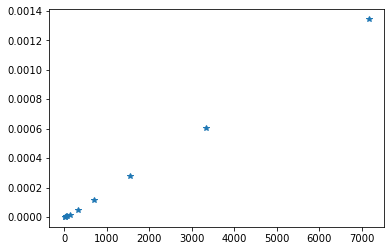

In [8]:
def min_heapify(h: np.ndarray, i: int):
    """Recibe un array h de Numpy y aplica la operacion de heapify 
    al elemento situado en la posicion i"""
    while 2*i+1 < len(h):
        n_i = i
        if h[i] > h[2*i+1]:
            n_i = 2*i+1
        if 2*i+2 < len(h) and h[i] > h[2*i+2] and h[2*i+2] < h[n_i]:
            n_i = 2*i+2
        if n_i > i:
            h[i], h[n_i] = h[n_i], h[i]
            i = n_i
        else:
            return
        
def insert_min_heap(h: np.ndarray, k: int)-> np.ndarray:
    """Inserta el entero k en el min heap contenido en h y devuelve el nuevo min heap."""
    h += [k]
    j = len(h) - 1
    try:
        while j >= 1 and h[(j-1) // 2] > h[j]:
            h[(j-1) // 2], h[j] = h[j], h[(j-1) // 2]
            j = (j-1) // 2
    except:
        print("Error insertando")
    else:
        return h

def create_min_heap(h: np.ndarray):
    """Crea un min heap sobre el array de Numpy pasado como argumento"""
    m = len(h) // 2
    try:
        for j in range(m, -1, -1):
            i=j
            while 2*i+1 < len(h):
                n_i = i
                if h[i] > h[2*i+1]:
                    n_i = 2*i+1
                if 2*i+2 < len(h) and h[i] > h[2*i+2] and h[2*i+2] < h[n_i]:
                    n_i = 2*i+2
                if n_i > i:
                    h[i], h[n_i] = h[n_i], h[i]
                    i = n_i
                else:
                    break
    except:
        print("Error creando min heap")
    
    else:
        return
l_times = []
for i, size in enumerate(range(5, 15)):
    t= np.ndarray([])
    t = list(range(2**i * size))
    timings = %timeit -n 100 -r 10 -o -q create_min_heap(t)
    l_times.append([len(t), timings.best])

times = np.array(l_times)
l_times
lc=np.array(l_times)
x=lc[:,0]
y=lc[:,1]
x, y 
plt.plot(x,y, '*')

In [9]:
def pq_ini():
    """inicializa una cola de prioridad vacıa."""
    try:
        np.ndarray: c
        c=[]
    except:
        print("Error iniciando pq")
    else:
        return c

def pq_insert(h: np.ndarray, k: int)-> np.ndarray:
    """inserta el elemento k en la cola de prioridad h y devuelva la nueva cola."""
    try:
        h= insert_min_heap(h,k)
    except:
        print("Error insertando en pq")
    else:
        return h

def pq_remove (h: np.ndarray) -> tuple[int, np.ndarray]:
    """Elimina el elemento con el menor valor de prioridad de h y 
    devuelve dicho elemento y la nueva cola."""
    try:
        remove=h[0]
        h[0]= h[len(h)-1]
        min_heapify(h[1:], 0)
    except:
        print("Error eliminando de pq")
    else:
        return remove, h[1:]
    


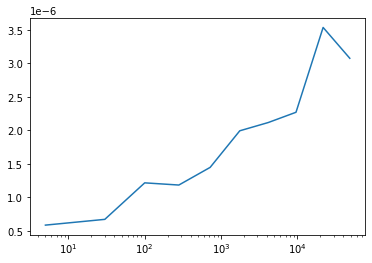

In [10]:
l_times = []
for i, size in enumerate(range(5, 100, 10)):
    t = list(range(2**i * size))
    key = size + 1
    timings = %timeit -n 10 -r 100 -o -q rec_bb(t, 0, len(t) - 1, key)
    l_times.append([len(t), timings.best])

times = np.array(l_times)
l_times
lc=np.array(l_times)
x=lc[:,0]
y=lc[:,1]
x, y 
plt.xscale('log')
plt.plot(x,y)

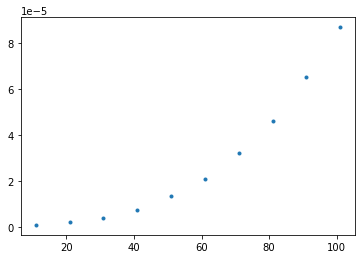

In [16]:
l_timingsd
las=np.array(l_timingsd)
x=las[:,0]
y=las[:,1]
x,y
plt.plot(x,y,'.')

In [12]:
from sklearn.linear_model import LinearRegression

In [3]:
def fit_func_2_times(timings: np.ndarray, func_2_fit: callable):
    """Ajusta linealmente los valores de la funcion func_2_fit a
    los tiempos en timings.
    Esto es, calculamos valores a, b para que la funcion a*f(dim) + b
    se ajuste a los tiempos medidos.
    """
    if len(timings.shape) == 1:
        timings = timings.reshape(-1, 1)
    values = func_2_fit(timings[ :, 0]).reshape(-1, 1)
    #normalizar timings
    times = timings[ : , 1] / timings[0, 1]
    #ajustar a los valores en times un modelo lineal sobre los valores en values
    lr_m = LinearRegression()
    lr_m.fit(values, times)
    return lr_m.predict(values)

def func_2_fit(n):
    return n*np.log(n)

fit_func_2_times(timings,func_2_fit(dim))
l_timingsd.append([dim, timings.best])
l_timings
la=np.array(l_timings)
x=la[:,0]
y=la[:,1]
x,y
plt.plot(x,y,'*')

NameError: name 'timings' is not defined

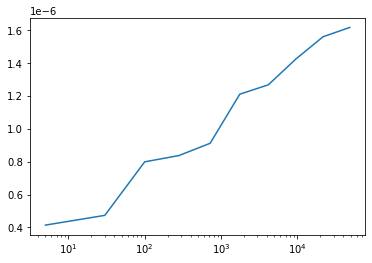

In [17]:
l_times = []
for i, size in enumerate(range(5, 100, 10)):
    t = list(range(2**i * size))
    key = size + 1
    timings = %timeit -n 100 -r 50 -o -q bb(t, 0, len(t) - 1, key)
    l_times.append([len(t), timings.best])

times = np.array(l_times)
l_times
lc=np.array(l_times)
x=lc[:,0]
y=lc[:,1]
x, y 
plt.xscale('log')
plt.plot(x,y)